In [1]:
import pandas as pd
import numpy as np

transactions = pd.read_csv("../HI-Small_Trans.csv")
transactions.columns = ["Timestamp", "From Bank", "From Account", "To Bank", "To Account",
                         "Amount Received", "Receiving Currency", "Amount Paid", "Payment Currency",
                         "Payment Format", "Is Laundering"]
accounts = pd.read_csv("../HI-Small_accounts.csv")

In [2]:
transactions.head()

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [3]:
transactions.columns

Index(['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='object')

In [4]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   From Account        object 
 3   To Bank             int64  
 4   To Account          object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [5]:
transactions.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00


In [6]:
accounts.head()

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [7]:
accounts.columns

Index(['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name'], dtype='object')

## 1. Column profile — transactions

In [8]:
for c in transactions.columns:
    print(f"{c:20s} dtype={str(transactions[c].dtype):8s} nunique={transactions[c].nunique()}")

Timestamp            dtype=object   nunique=15018
From Bank            dtype=int64    nunique=30470


From Account         dtype=object   nunique=496995
To Bank              dtype=int64    nunique=15811


To Account           dtype=object   nunique=420636


Amount Received      dtype=float64  nunique=915161
Receiving Currency   dtype=object   nunique=15


Amount Paid          dtype=float64  nunique=923873


Payment Currency     dtype=object   nunique=15


Payment Format       dtype=object   nunique=7
Is Laundering        dtype=int64    nunique=2


## 2. accounts.csv structure

In [9]:
print("rows:", len(accounts))
print("unique Account Number:", accounts["Account Number"].nunique())
print("unique Bank Name:", accounts["Bank Name"].nunique())
print("unique Bank ID:", accounts["Bank ID"].nunique())
print("unique Entity ID:", accounts["Entity ID"].nunique())
print("unique Entity Name:", accounts["Entity Name"].nunique())
print("dup Account Number rows:", accounts["Account Number"].duplicated().sum())
print("\nmissing values:\n", accounts.isna().sum())

acc_per_entity = accounts.groupby("Entity ID")["Account Number"].nunique()
print("\nentities with >1 account:", (acc_per_entity > 1).sum())
print("accounts per entity describe:\n", acc_per_entity.describe())

banks_per_account = accounts.groupby("Account Number")["Bank ID"].nunique()
print("\naccounts spanning >1 bank:", (banks_per_account > 1).sum())

print("\nentity type breakdown:\n", accounts["Entity Name"].str.extract(r"^([A-Za-z ]+?)\s*#")[0].value_counts())

rows: 518581


unique Account Number: 518573
unique Bank Name: 20053


unique Bank ID: 30470
unique Entity ID: 166207


unique Entity Name: 166207


dup Account Number rows: 8

missing values:
 Bank Name         0
Bank ID           0
Account Number    0
Entity ID         0
Entity Name       0
dtype: int64



entities with >1 account: 63518
accounts per entity describe:
 count    166207.000000
mean          3.120091
std          38.985131
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        7820.000000
Name: Account Number, dtype: float64



accounts spanning >1 bank: 8



entity type breakdown:
 0
Partnership            189683
Corporation            172351
Sole Proprietorship    149048
Country                  6692
Individual                740
Direct                     67
Name: count, dtype: int64


## 3. Join verification — Bank ID and Account Number vs transactions

In [10]:
tx_banks = set(transactions["From Bank"]).union(set(transactions["To Bank"]))
acc_bankid = set(accounts["Bank ID"])
print("unique tx bank codes:", len(tx_banks))
print("unique acc Bank ID:", len(acc_bankid))
print("overlap tx banks vs acc Bank ID:", len(tx_banks & acc_bankid))

tx_accounts = set(transactions["From Account"]).union(set(transactions["To Account"]))
acc_accnum = set(accounts["Account Number"])
print("\nunique tx account ids:", len(tx_accounts))
print("unique acc Account Number:", len(acc_accnum))
print("overlap tx accounts vs acc Account Number:", len(tx_accounts & acc_accnum))

unique tx bank codes: 30470
unique acc Bank ID: 30470
overlap tx banks vs acc Bank ID: 30470



unique tx account ids: 515080
unique acc Account Number: 518573
overlap tx accounts vs acc Account Number: 515080


## 4. Temporal analysis

In [11]:
transactions["ts"] = pd.to_datetime(transactions["Timestamp"])

print("first:", transactions["ts"].min(), "last:", transactions["ts"].max())
ndays = (transactions["ts"].max() - transactions["ts"].min()).days + 1
print("days span:", ndays)
print("tx/day avg:", len(transactions) / ndays)

by_day = transactions["ts"].dt.date.value_counts().sort_index()
print("\nbusiest day:", by_day.idxmax(), by_day.max())

by_hour = transactions["ts"].dt.hour.value_counts().sort_index()
print("busiest hour:", by_hour.idxmax(), by_hour.max())

by_wd = transactions["ts"].dt.day_name().value_counts()
print("busiest weekday:", by_wd.idxmax(), by_wd.max())

first: 2022-09-01 00:00:00 last: 2022-09-18 16:18:00
days span: 18
tx/day avg: 282130.27777777775



busiest day: 2022-09-01 1114921


busiest hour: 0 634726


busiest weekday: Thursday 1597740


## 5. Distribution analysis

In [12]:
transactions["log_amount"] = np.log1p(transactions["Amount Received"])
print(transactions["log_amount"].describe())

print("\nPayment Format counts:\n", transactions["Payment Format"].value_counts())
print("\nReceiving Currency counts:\n", transactions["Receiving Currency"].value_counts())
print("\ntop From Bank counts:\n", transactions["From Bank"].value_counts().head(10))
print("\ncurrency mismatch rows (Receiving != Payment):",
      (transactions["Receiving Currency"] != transactions["Payment Currency"]).sum())

count    5.078345e+06
mean     7.419097e+00
std      3.386991e+00
min      9.999995e-07
25%      5.216945e+00
50%      7.252770e+00
75%      9.421190e+00
max      2.767628e+01
Name: log_amount, dtype: float64

Payment Format counts:
 Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64



Receiving Currency counts:
 Receiving Currency
US Dollar            1879341
Euro                 1172017
Swiss Franc           237884
Yuan                  206551
Shekel                194988
Rupee                 192065
UK Pound              181255
Ruble                 157361
Yen                   156319
Bitcoin               148151
Canadian Dollar       141357
Australian Dollar     138511
Mexican Peso          111030
Saudi Riyal            89971
Brazil Real            71544
Name: count, dtype: int64

top From Bank counts:
 From Bank
70     449859
10      81629
12      79754
1       62211
15      52511
220     52417
20      41008
3       38413
7       31086
211     30451
Name: count, dtype: int64



currency mismatch rows (Receiving != Payment): 72170


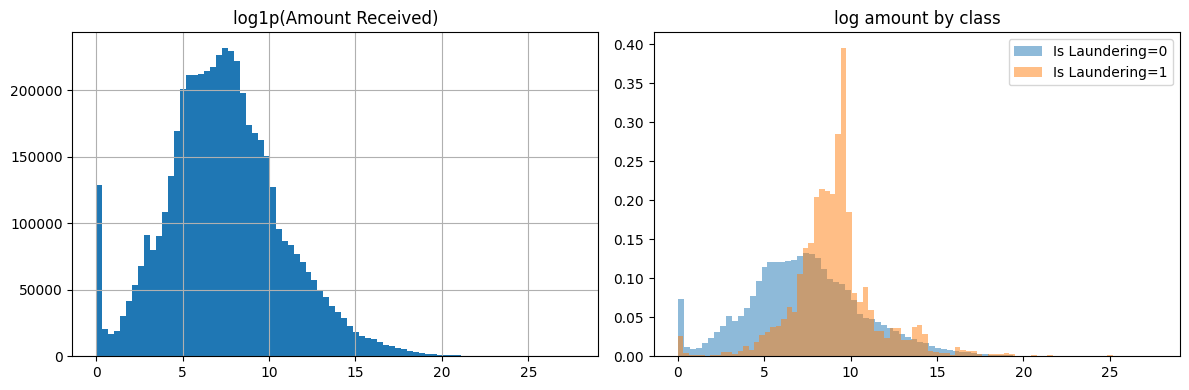

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
transactions["log_amount"].hist(bins=80, ax=axes[0])
axes[0].set_title("log1p(Amount Received)")

for label, sub in transactions.groupby("Is Laundering"):
    axes[1].hist(sub["log_amount"], bins=80, alpha=0.5, density=True, label=f"Is Laundering={label}")
axes[1].legend()
axes[1].set_title("log amount by class")
plt.tight_layout()
plt.show()

## 6. Class analysis — normal vs laundering

In [14]:
g = transactions.groupby("Is Laundering")
print("counts:\n", g.size())
print("\nmean Amount Received:\n", g["Amount Received"].mean())
print("\nmedian Amount Received:\n", g["Amount Received"].median())

print("\nPayment Format by class (normalized within class):")
print(pd.crosstab(transactions["Payment Format"], transactions["Is Laundering"], normalize="columns"))

print("\nCurrency by class (normalized within class):")
print(pd.crosstab(transactions["Receiving Currency"], transactions["Is Laundering"], normalize="columns"))

print("\nactive hour by class (normalized within class):")
print(pd.crosstab(transactions["ts"].dt.hour, transactions["Is Laundering"], normalize="columns"))

print("\ntop sender banks, normal:\n", transactions[transactions["Is Laundering"] == 0]["From Bank"].value_counts(normalize=True).head(5))
print("\ntop sender banks, laundering:\n", transactions[transactions["Is Laundering"] == 1]["From Bank"].value_counts(normalize=True).head(5))

counts:
 Is Laundering
0    5073168
1       5177
dtype: int64

mean Amount Received:
 Is Laundering
0    5.957962e+06
1    3.613531e+07
Name: Amount Received, dtype: float64

median Amount Received:
 Is Laundering
0    1407.51
1    8667.21
Name: Amount Received, dtype: float64

Payment Format by class (normalized within class):


Is Laundering          0         1
Payment Format                    
ACH             0.117543  0.865946
Bitcoin         0.028786  0.010817
Cash            0.096741  0.020862
Cheque          0.367425  0.062585
Credit Card     0.260807  0.039791
Reinvestment    0.094824  0.000000
Wire            0.033875  0.000000

Currency by class (normalized within class):


Is Laundering              0         1
Receiving Currency                    
Australian Dollar   0.027278  0.024532
Bitcoin             0.029192  0.010817
Brazil Real         0.014091  0.011010
Canadian Dollar     0.027838  0.024725
Euro                0.230752  0.265018
Mexican Peso        0.021868  0.017771
Ruble               0.030992  0.025691
Rupee               0.037826  0.032258
Saudi Riyal         0.017661  0.072243
Shekel              0.038416  0.018350
Swiss Franc         0.046853  0.037280
UK Pound            0.035702  0.025497
US Dollar           0.370070  0.369326
Yen                 0.030782  0.029940
Yuan                0.040678  0.035542

active hour by class (normalized within class):


Is Laundering         0         1
ts                               
0              0.125080  0.033997
1              0.038157  0.029361
2              0.038039  0.031872
3              0.038064  0.028202
4              0.038046  0.029747
5              0.038184  0.036314
6              0.038289  0.039985
7              0.038071  0.037667
8              0.037977  0.049836
9              0.037991  0.041916
10             0.038042  0.045200
11             0.038084  0.056983
12             0.037972  0.064902
13             0.037891  0.056403
14             0.037946  0.053892
15             0.038360  0.050802
16             0.038062  0.060073
17             0.038023  0.049643
18             0.038056  0.049256
19             0.037963  0.044620
20             0.037979  0.025884
21             0.037854  0.029747
22             0.037789  0.024725
23             0.038082  0.028974



top sender banks, normal:
 From Bank
70    0.088549
10    0.016080
12    0.015706
1     0.012253
15    0.010342
Name: proportion, dtype: float64

top sender banks, laundering:
 From Bank
70     0.122272
12     0.014680
20     0.012942
119    0.011397
10     0.009851
Name: proportion, dtype: float64


## 7. Relationship analysis — sender/receiver degree

In [15]:
out_deg = transactions.groupby("From Account")["To Account"].nunique()
in_deg = transactions.groupby("To Account")["From Account"].nunique()

print("out-degree (unique receivers per sender) describe:\n", out_deg.describe())
print("\nin-degree (unique senders per receiver) describe:\n", in_deg.describe())

print("\naccounts with out_deg>10 (many outgoing / fan-out candidates):", (out_deg > 10).sum())
print("accounts with in_deg>10 (many incoming / fan-in candidates):", (in_deg > 10).sum())
print("accounts with out_deg==1 and in_deg==1 (isolated/simple pass-through):",
      len(set(out_deg[out_deg == 1].index) & set(in_deg[in_deg == 1].index)))

out-degree (unique receivers per sender) describe:
 count    496995.000000
mean          2.043755
std          24.630636
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max       14230.000000
Name: To Account, dtype: float64

in-degree (unique senders per receiver) describe:
 count    420636.000000
mean          2.414762
std           2.721735
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         545.000000
Name: From Account, dtype: float64

accounts with out_deg>10 (many outgoing / fan-out candidates): 4027
accounts with in_deg>10 (many incoming / fan-in candidates): 2872


accounts with out_deg==1 and in_deg==1 (isolated/simple pass-through): 96600


## 8. Graph characteristics

In [16]:
print("unique senders:", transactions["From Account"].nunique())
print("unique receivers:", transactions["To Account"].nunique())
print("unique accounts total:", len(tx_accounts))

edges = transactions[["From Account", "To Account"]].drop_duplicates()
print("unique edges (sender,receiver pairs):", len(edges))

self_loops = (transactions["From Account"] == transactions["To Account"]).sum()
print("self loops (rows):", self_loops)

pair_counts = transactions.groupby(["From Account", "To Account"]).size()
print("repeat pairs (edge used >1 time):", (pair_counts > 1).sum())
print("max repeats on a single pair:", pair_counts.max())

unique senders: 496995


unique receivers: 420636
unique accounts total: 515080


unique edges (sender,receiver pairs): 1015736
self loops (rows): 591212


repeat pairs (edge used >1 time): 561575
max repeats on a single pair: 89


## 9. Pattern file — HI-Small_Patterns.txt

In [17]:
import re
from collections import Counter

pattern_types = Counter()
n_data_rows = 0
n_groups = 0
with open("../HI-Small_Patterns.txt") as f:
    for line in f:
        line = line.strip()
        if line.startswith("BEGIN LAUNDERING ATTEMPT"):
            n_groups += 1
            m = re.search(r"BEGIN LAUNDERING ATTEMPT - ([A-Z-]+)", line)
            pattern_types[m.group(1)] += 1
        elif line and not line.startswith("END"):
            n_data_rows += 1

print("laundering-attempt groups:", n_groups)
print("data rows across all groups:", n_data_rows)
print("pattern type counts:\n", pattern_types)

laundering_tx_rows = (transactions["Is Laundering"] == 1).sum()
print("\nIs Laundering==1 rows in transactions.csv:", laundering_tx_rows)
print("pattern-file row count vs labeled tx row count differ:",
      n_data_rows != laundering_tx_rows,
      f"({n_data_rows} vs {laundering_tx_rows})")

laundering-attempt groups: 370
data rows across all groups: 3209
pattern type counts:
 Counter({'CYCLE': 54, 'GATHER-SCATTER': 51, 'BIPARTITE': 49, 'FAN-OUT': 48, 'SCATTER-GATHER': 44, 'STACK': 43, 'RANDOM': 41, 'FAN-IN': 40})

Is Laundering==1 rows in transactions.csv: 5177
pattern-file row count vs labeled tx row count differ: True (3209 vs 5177)
